<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week10_0505_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.2 파이토치 기초 문법

## 2.2.1 텐서 다루기

**텐서 생성 및 변환**

넘파이의 ndarray 와 비슷하며 GPU에서의 연산도 가능.

In [ ]:
# 텐서 생성

import torch

print(torch.tensor([[1,2], [3,4]]))  # 2차원 형태의 텐서 생성
print(torch.tensor([[1,2], [3,4]], device = "cuda:0")) #GPU에 텐서 생성
print(torch.tensor([[1,2], [3,4]], dtype=torch.float64)) # dtype을 이용하여 텐서 생성

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]], device='cuda:0')
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


In [ ]:
# 텐서를 ndarray로 변환

temp = torch.tensor([[1,2], [3,4]])
print(temp.numpy()) # 텐서를  ndarray로 변환

temp = torch.tensor([[1,2], [3,4]], device="cuda:0")
print(temp.to("cpu").numpy())  # GPU상의 텐서를 CPU의 텐서로 변환한 후 ndarray로 변환

[[1 2]
 [3 4]]
[[1 2]
 [3 4]]


**텐서의 인덱스 조작**

배열처럼 인텍스를 바로 지정하거나 슬라이스 등을 사용

- 텐서의 자료형
    - torch. FloatTensor: 32비트의 부동 소수점
    - torch. DoubleTensor: 64비트의 부동 소수점
    - torch. LongTensor: 64비트의 부호가 있는 정수

In [ ]:
temp = torch.FloatTensor([1,2,3,4,5,6,7])   # 파이토치로 1차원벡터생성
print(temp[0], temp[1], temp[-1])           # 인텍스로 접근
print('-----------------')
print(temp[2:5], temp[4:-1])                # 슬라이스로 접근

tensor(1.) tensor(2.) tensor(7.)
-----------------
tensor([3., 4., 5.]) tensor([5., 6.])


**텐서 연산**

텐서는 넘파이의 ndarray처럼 다양한 수학 연산이 가능하며 GPU를 사용하면 더 빠르게 연산 가능.

텐서 간의 타입이 다르면 연산 불가능.

In [ ]:
# 벡터 두 개 생성, 사칙 연산

v = torch.tensor([1,2,3])
w = torch.tensor([3,4,6])

print(w-v) # 길이가 같은 벡터 간 뺄셈 연산

tensor([2, 2, 3])


**텐서의 차원 조작**

- view: 넘파이의 reshape과 유사함.
- stack: 텐서를 결합함.
- cat: 다른 길이의 텐서를 하나로 병합할 때 사용함.
- transpose: 행렬의 전치 외에도 차원의 순서를 변경할 때도 사용됨.

In [ ]:
# 텐서의 차원 조작

temp = torch.tensor([
    [1,2], [3,4]           #  2x2 행렬생성
])

print(temp.shape)
print('-----------------')
print(temp.view(4,1))      # 4x1로 변형
print('-----------------')
print(temp.view(-1))       # 1차원으로 변형
print('-----------------')
print(temp.view(1, -1))    # 1x?, 즉 1x4로 변형
print('-----------------')
print(temp.view(-1, 1))    # ?x1, 즉 4x1로 변형

torch.Size([2, 2])
-----------------
tensor([[1],
        [2],
        [3],
        [4]])
-----------------
tensor([1, 2, 3, 4])
-----------------
tensor([[1, 2, 3, 4]])
-----------------
tensor([[1],
        [2],
        [3],
        [4]])


## 2.2.2 데이터 준비

- 데이터 유형에 따른 처리
    - 데이터가 이미지일 경우
    
    분산된 파일에서 데이터를 읽은 후 전처리를 하고 배치 단위로 분할하여 처리

    -  데이터가 텍스트일 경우
    
    임베딩 과정을 거쳐 서로 다른 길이의 시퀀스를 배치 단위로 분할하여 처리

- 파이토치를 이용하여 데이터셋을 불러오는 방법
    - 단순하게 파일을 불러와서 사용
    - 커스텀 데이터셋을 만들어서 사용
    - 파이토치에서 제공하는 데이터셋 사용

---

**단순하게 파일을 불러와서 사용**

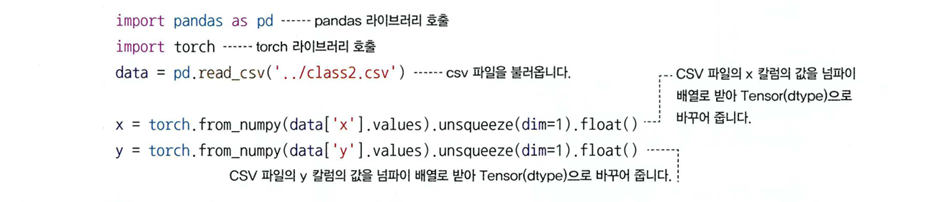

---

**커스텀 데이터셋을 만들어서 사용**

커스텀 데이터셋: 데이터를 한 번에 다 부르지 않고 조금씩 나누어 불러서 사용히는 방식

> CustomDataset 클래스를 구현하기 위해 취해야 하는 형태

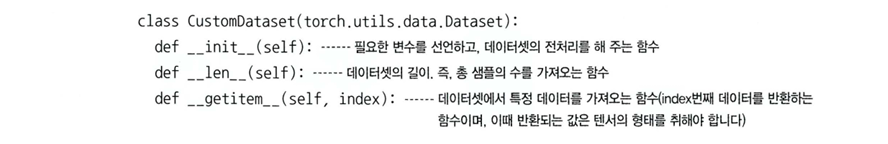

> 커스텀 데이터셋 구현 방법에 대한 예제

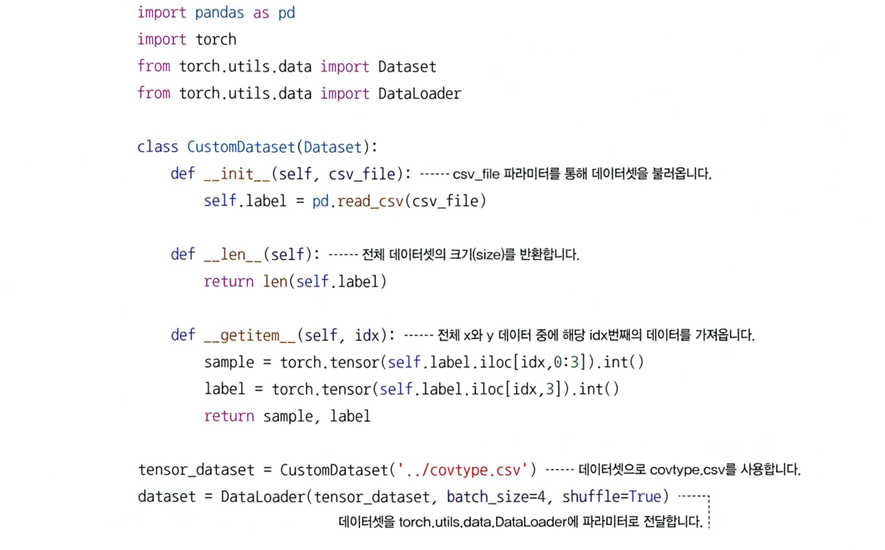

*** NOTE torch.utils.data.DataLoader**

- 데이터로더(DataLoader) 객체
    - 학습에 사용될 데이터 전체를 보관했다가 모델 학습을 할 때 배치 크기만큼 데이터를 꺼내서 사용함.
    - 이때 주의할 것은 데이터를 미리 잘라 놓는 것이 아니라 내부적으로 반복자(iterator)에 포함된 인덱스(index)를 이용하여 배치 크기만큼 데이터를 반환한다는 것.

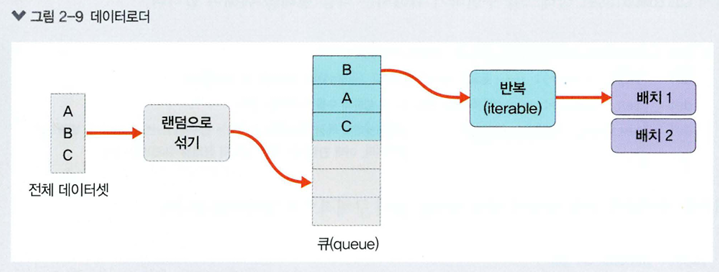

---

**파이토치에서 제공하는 데이터셋 사용**

토치비전(torchvision): 파이토치에서 제공하는 데이터셋들이 모여 있는 패키지

In [ ]:
pip install requests

> MNIST 데이터셋을 내려받는 예제

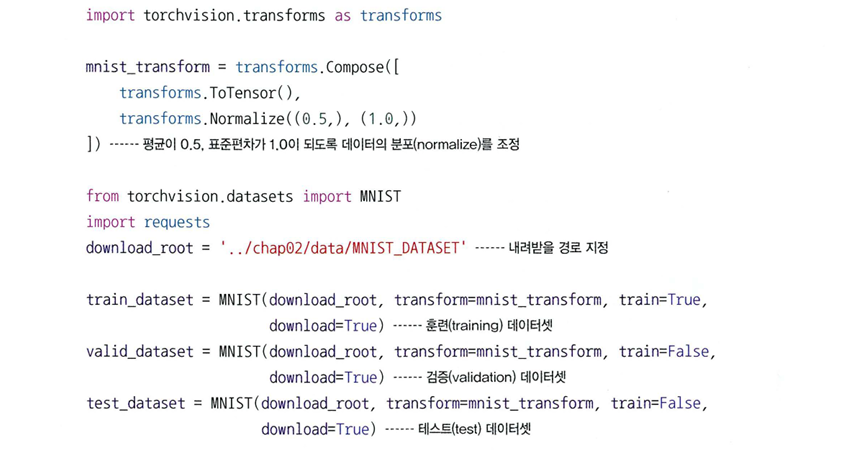

---
---

## 2.2.3 모델 정의

파이토치에서 모델을 정의하기 위해서는 모듈(module)을 상속한 클래스를 사용함

- 계층(layer) : 모듈 또는 모듈을 구성하는 한 개의 계층으로 합성곱층, 선형계층 등이 있음.
- 모듈(module) : 한 개 이상의 계층이 모여서 구성된 것으로, 모듈이 모여 새로운 모듈을 만들 수 있음.
- 모델(model) : 최종적으로 원하는 네트워크로, 한 개의 모듈이 모델이 될 수 있음

**단순 신경망을 정의하는 방법**

nn.Module을 상속받지 않는 매우 단순한 모델을 만들 때 사용하며, 구현이 쉽고 단순하다는 장점이 있음.

```python
model = nn.Linear(in_features=1, out_features=1, bias=True)
```

---

**nn.Module( )을 상속하여 정의하는 방법**

- 파이토치에서 nn.Module을 상속받는 모델은 기본적으로 `__init__()`과 `forward()` 함수를 포함.
    - `__init__()`: 모델에서 사용될 모듈(nn.Linear, nn.Conv2d), 활성화 함수 등을 정의함.
    - `forward()` 함수: 모델에서 실행되어야 하는 연산을 정의함.

In [ ]:
# 파이토치에서 모델을 정의하는 코드

from torch.nn import Module, Linear, Sigmoid

class MLP(Module):
    def __init__(self, inputs):
        super(MLP, self).__init__()
        self.layer = Linear(inputs, 1) # 계층 정의
        self.actiation = Sigmoid()     # 활성화 함수 정의

    def forward(self, x):
        x = self.layer(x)
        x = self.activation(x)
        return x

---

**Sequential 신경망을 정의하는 방법**

- nn.Sequential:
    - `__init__()`에서 사용할 네트워크 모델들 정의
    - `forward()` 함수에서는 모델에서 실행되어야 할 계산을 좀 더 가독성이 뛰어나게 코드로 작성할 수 있음.
    - nn.Sequential은 모델의 계층이 복잡할수록 효과가 뛰어남.

In [ ]:
# Sequential 객체는 그 안에 포함된 각 모듈을 순차적으로 실행함

import torch.nn as nn
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=30, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(in_features=30*5*5, out_features=10, bias=True),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.shape[0], -1)
        x = self.layer3(x)
        return x

model = MLP()

print("Printing Children\n---------------------------")
print(list(model.children()))
print("\n\nPrinting Modules\n---------------------------")
print(list(model.modules()))

Printing Children
---------------------------
[Sequential(
  (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Linear(in_features=750, out_features=10, bias=True)
  (1): ReLU(inplace=True)
)]


Printing Modules
---------------------------
[MLP(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Linear(in_f

*** NOTE model.modules() & model.children()**

model.modules()는 모델의 네트워크에 대한 모든 노드를 반환하며， model.children()은 같은 수준(level)의 하위 노드를 반환함.

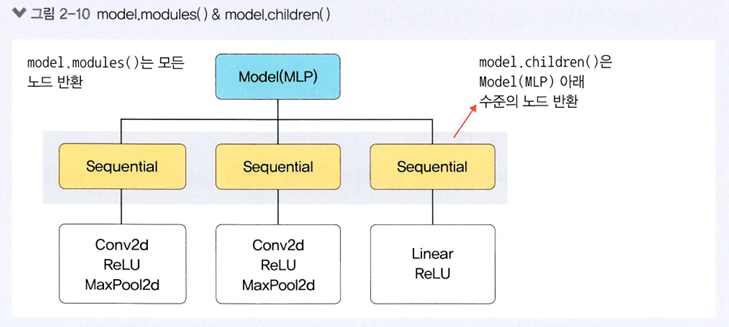

---

**함수로 신경망을 정의하는 방법**

- Sequential을 이용하는 것과 동일
- 장점: 변수에 저장해 놓은 계층들을 재사용할 수 있음.
- 단점: 모델이 복잡해짐.

복잡한 모델의 경우에는 함수를 이용하는 것보다 nn.Module()을 상속받아 사용하는 것이 편리함.

In [ ]:
def MLP(in_features=1, hidden_features=20, out_features=1):
    hidden = nn.Linear(in_features=in_features, out_features=hidden_features,
                       bias=True)
    activation=nn.ReLU()
    output = nn.Linear(in_features=hidden_features, out_features=out_features,
                       bias=True)
    net = nn.Sequential(hidden, activation, output)
    return net

---
---

## 2.2.4 모델의 파라미터 정의

**모델을 학습하기 전에 필요한 파라미터들 정의**

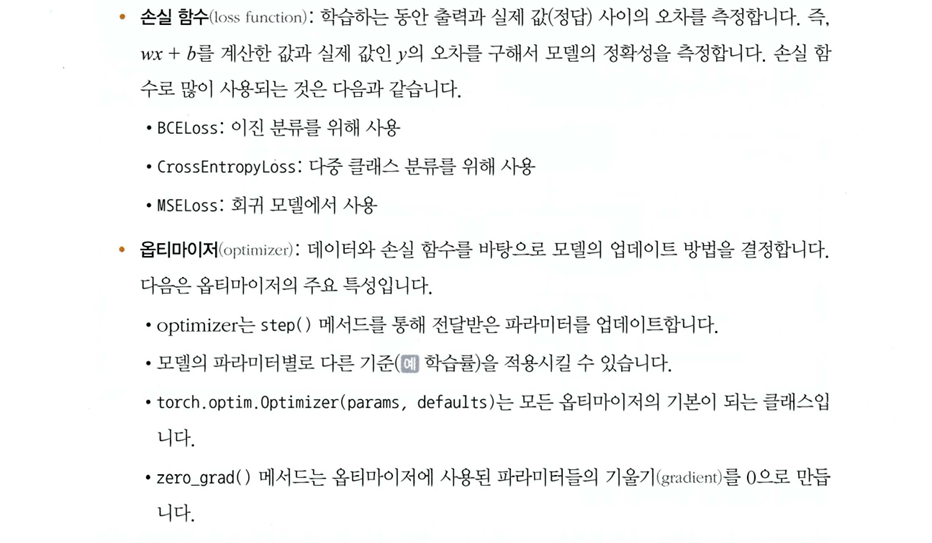

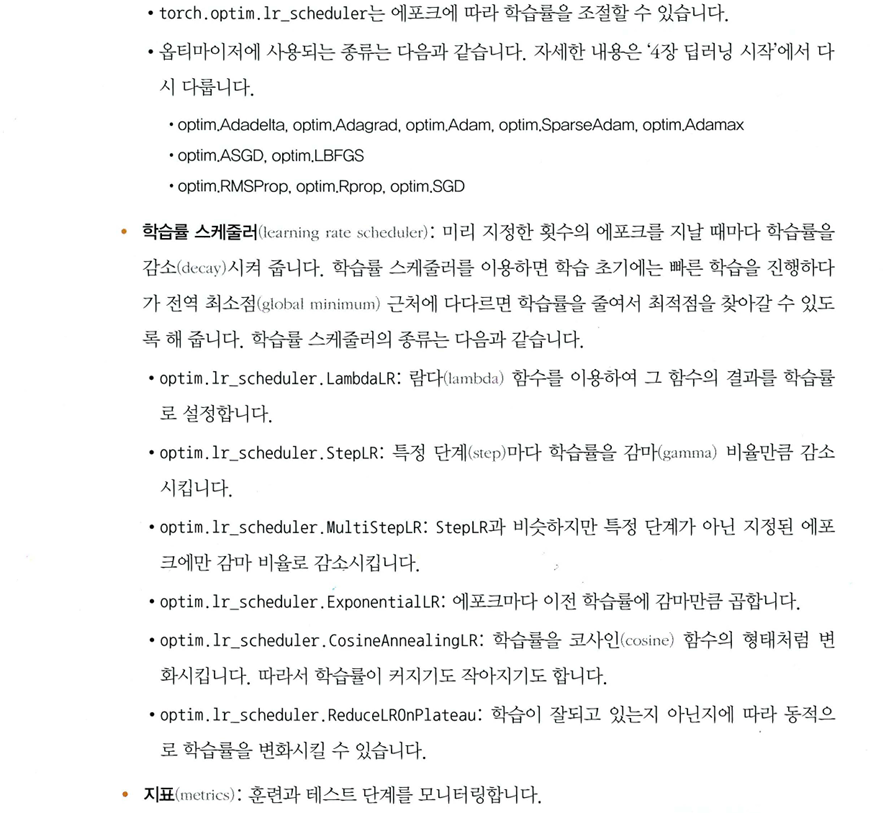

*** NOTE 전역 최소점과 최적점**

- 손실 함수: 실제 값과 예측 값 차이를 수치화해 주는 함수. 이 오차값이 클수록 손실 함수의 값이 크고, 오차값이 작을수록 손실 함수의 값이 작아짐.
    - 학습목표: 이 손실 함수의 값을 최소화하는 가중치와 바이어스를 찾는 것.

- 전역 최소점(global minimum): 오차가 가장 작을 때의 값.

    우리가 최종적으로 찾고자 하는 것, 최적점
- 지역 최소점(Iocal minimum): 전역 최소점을 찾아가는 과정에서 만나는 홀(hole)과 같은 것.
    
     옵티마이저가 지역 최소점에서 학습을 멈추면 최솟값을 갖는 오차를 찾을 수 없는 문제가 발생함.

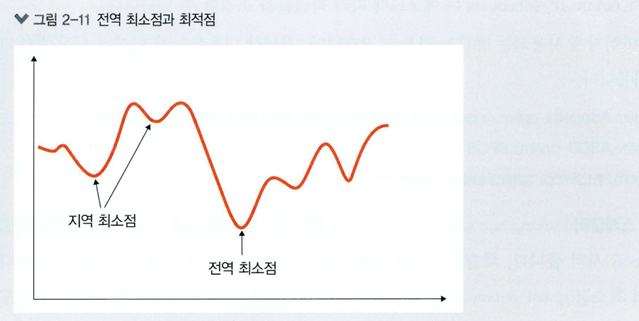

```python
# 모델의 파라미터를 정의하는 예시 코드

from torch.optim import optimizer

criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer=optimizer,
                                              lr_lambda=lambda epoch: 0.95 ** epoch)
for epoch in range(1, 100+1):   # 에포크 수만큼 데이터를 반복하여 처리
    for x, y in dataloader:     # 배치 크기만큼 데이터를 가져와서 학습 진행
        optimizer.zero_grad()
    loss_fn(model(x), y).backward()
    optimizer.step()
    scheduler.step()

```

## 2.2.5 모델 훈련

학습: `y = wx + b` 라는 함수에서 w와 b의 적절한 값을 찾는다는 의미

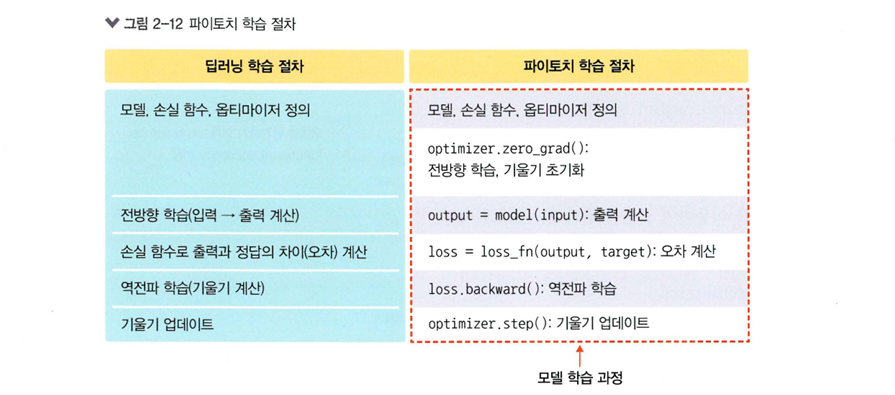

- optimizer.zero_grad() 메서드를 이용하여 기울기를 초기화
    - 파이토치 기울기 계산: loss.backward() 메서드 이용 -> 기울기 값 누적됨.
    - 따라서 누적 계산이 필요하지 않을 때는 입력 값을 모델에 적용하기 전에 optimizer.zero_grad() 메서드를 호출하여 미분 값이 누적되지 않게 초기화해 주어야함

- loss.backward() 메서드를 이용하여 기울기를 자동 계산
    - loss.backward()는 배치가 반복될 때마다 오차가 중첩적으로 쌓이게 됨.
    - 따라서 매번 zero_grad()를 사용하여 미분 값을 0으로 초기화

```python
# 모델을 훈련시키는 예시 코드

for epoch in range(100):
    yhat = model(x_train)
    loss = criterion(yhat, y_train)
    optimizer.zero_grad()     # 오차가 중칩적으로 쌓이지 않도록 초기화
    loss.backward()
    optimizer.step()
```

## 2.2.6 모델 평가

- 모델에 대한 평가
    - 함수 이용
    - 모듈 이용

In [ ]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 21.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
# 함수를 이용하여 모델을 평가하는 코드

import torch
import torchmetrics

preds = torch.randn(10,5).softmax(dim=1)
target = torch.randint(5, (10,))

acc = torchmetrics.functional.accuracy(preds, target, task="multiclass", num_classes=5)  # torchmetrics.functional.accuracy 이용
print(acc)
# torchmetrics.functional.accuracy의 시그니처가 바뀌어서, 이제 task 인자를 꼭 넘겨줘야 함.
# ex. 다중 클래스 분류, 클래스 수 = 5

tensor(0.2000)


```python
# 모듈을 이용하여 모델을 평가하는 코드

import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(".../chap02/tensorboard")       # 모니터링에 필요한 값들이 저장될 위치

for epoch in range(num_epochs):
    model.train() # 학습 모드로 전환(dropout=True)
    batch_loss = 0.0

    for i, (x, y) in enumerate(dataloader):
        x, y = x.to(device).float(), y.to(device).float()
        outputs = model(x)
        loss = criterion(outputs, y)
        writer.add_scalar("Loss", loss, epoch)         # 스칼라 값(오차)을 기록
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    writer.close()               # SummaryWriter가 더 이상 필요하지 않으면 close() 메서드 호출
```

## 2.2.7 훈련 과정 모니터링

1. 텐서보드를 설정(set up)
2. 텐서보드에 기록(write)
3. 텐서보드를 사용하여 모델 구조를 살펴봄.

In [ ]:
pip install tensorboard

In [ ]:
# 텐서보드 실행 명령어

!tensorboard --logdir=.../chap02/tensorboard --port=6006

2025-05-06 07:41:31.917839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746517291.938160    2021 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746517291.944354    2021 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.18.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C


*** NOTE model.traín() & model.eval()**

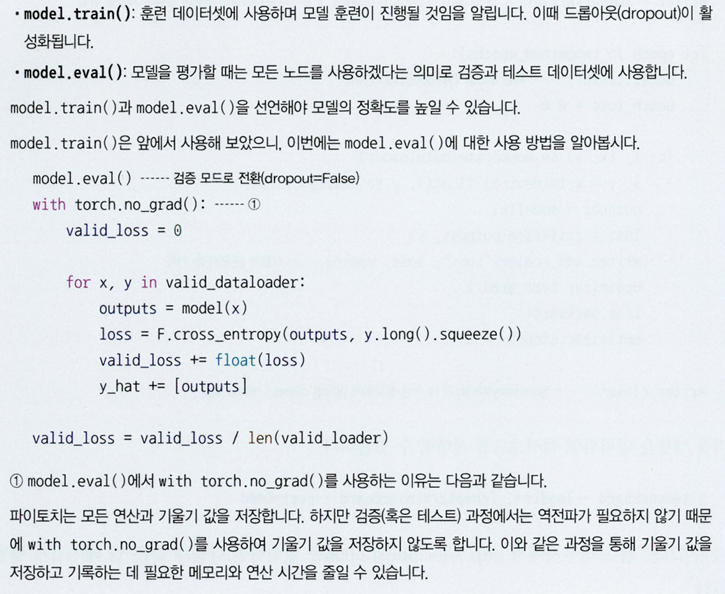